Exp 5. Spam Email Detection: Build a spam email filter using text
classification algorithms and perform comparative analysis. (Naïve
Bayes, Logistic Regression, Support Vector Machine, Decision Tree,
Random Forest)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix

In [ ]:

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
data=pd.read_csv("/content/drive/MyDrive/python-ml-lab/exp5_6_7_8/spam_email.csv")
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
data.shape

(5572, 2)

In [ ]:
data = data[['Category','Message']]

In [ ]:
data['Category'] = data['Category'].map({'ham':0, 'spam':1})


In [ ]:
X = data['Message']
y = data['Category']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Convert text data into numerical features using TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
LR=LogisticRegression()
LR.fit(X_train_vec,y_train)

NB=MultinomialNB()
NB.fit(X_train_vec,y_train)

DT=DecisionTreeClassifier()
DT.fit(X_train_vec,y_train)

RF=RandomForestClassifier()
RF.fit(X_train_vec,y_train)

svc=SVC()
svc.fit(X_train_vec,y_train)

SVC()

In [ ]:
LR_acc= accuracy_score(y_test,LR.predict(X_test_vec))
NB_acc= accuracy_score(y_test,NB.predict(X_test_vec))
DT_acc= accuracy_score(y_test,DT.predict(X_test_vec))
RF_acc= accuracy_score(y_test,RF.predict(X_test_vec))
svc_acc= accuracy_score(y_test,svc.predict(X_test_vec))

In [ ]:
print("LR Accuracy: ",LR_acc)
print("NB Accuracy: ",NB_acc)
print("DT Accuracy: ",DT_acc)
print("RF Accuracy: ",RF_acc)
print("SVC Accuracy: ",svc_acc)

LR Accuracy:  0.967713004484305
NB Accuracy:  0.9766816143497757
DT Accuracy:  0.9668161434977578
RF Accuracy:  0.9802690582959641
SVC Accuracy:  0.9847533632286996


In [ ]:
LR_precision = precision_score(y_test, LR.predict(X_test_vec))
NB_precision = precision_score(y_test, NB.predict(X_test_vec))
DT_precision = precision_score(y_test, DT.predict(X_test_vec))
RF_precision = precision_score(y_test, RF.predict(X_test_vec))
svc_precision = precision_score(y_test, svc.predict(X_test_vec))

In [ ]:
print("LR Precision: ", LR_precision)
print("NB Precision: ", NB_precision)
print("DT Precision: ", DT_precision)
print("RF Precision: ", RF_precision)
print("SVC Precision: ", svc_precision)

LR Precision:  1.0
NB Precision:  1.0
DT Precision:  0.9057971014492754
RF Precision:  1.0
SVC Precision:  1.0


In [ ]:
LR_recall = recall_score(y_test, LR.predict(X_test_vec))
NB_recall = recall_score(y_test, NB.predict(X_test_vec))
DT_recall = recall_score(y_test, DT.predict(X_test_vec))
RF_recall = recall_score(y_test, RF.predict(X_test_vec))
svc_recall = recall_score(y_test, svc.predict(X_test_vec))

In [ ]:
print("LR Recall: ", LR_recall)
print("NB Recall: ", NB_recall)
print("DT Recall: ", DT_recall)
print("RF Recall: ", RF_recall)
print("SVC Recall: ", svc_recall)

LR Recall:  0.7583892617449665
NB Recall:  0.825503355704698
DT Recall:  0.8389261744966443
RF Recall:  0.8523489932885906
SVC Recall:  0.8859060402684564


In [ ]:
from sklearn.metrics import f1_score

LR_f1 = f1_score(y_test, LR.predict(X_test_vec))
NB_f1 = f1_score(y_test, NB.predict(X_test_vec))
DT_f1 = f1_score(y_test, DT.predict(X_test_vec))
RF_f1 = f1_score(y_test, RF.predict(X_test_vec))
svc_f1 = f1_score(y_test, svc.predict(X_test_vec))

In [ ]:
print("LR F1-Score: ", LR_f1)
print("NB F1-Score: ", NB_f1)
print("DT F1-Score: ", DT_f1)
print("RF F1-Score: ", RF_f1)
print("SVC F1-Score: ", svc_f1)

LR F1-Score:  0.8625954198473282
NB F1-Score:  0.9044117647058824
DT F1-Score:  0.8710801393728222
RF F1-Score:  0.9202898550724637
SVC F1-Score:  0.9395017793594306


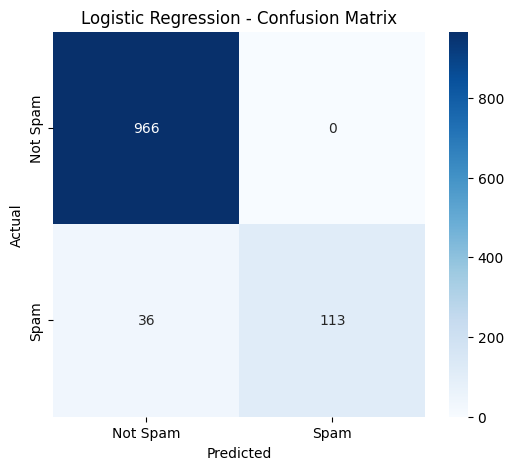

In [ ]:
# --- Logistic Regression ---
y_pred_lr = LR.predict(X_test_vec)
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

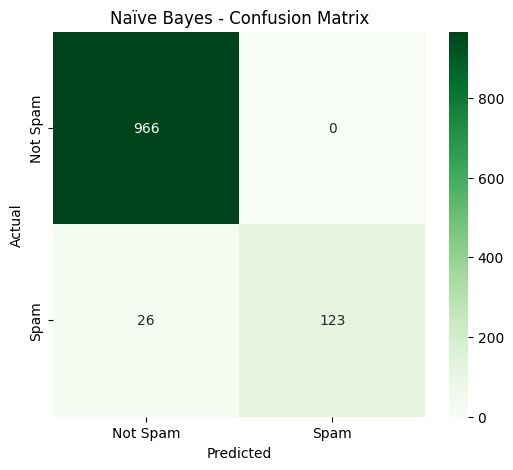

In [ ]:
# --- Naïve Bayes ---
y_pred_nb = NB.predict(X_test_vec)
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
plt.title("Naïve Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

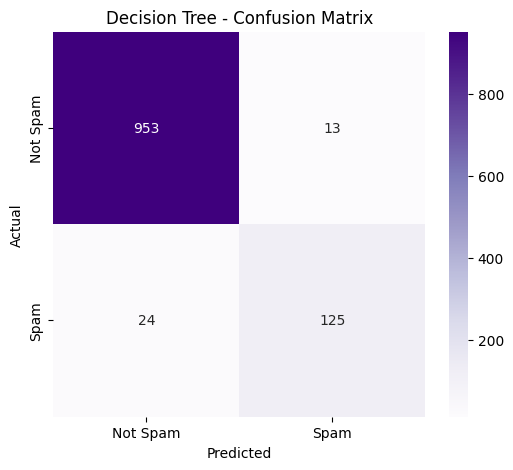

In [ ]:
# --- Decision Tree ---
y_pred_dt = DT.predict(X_test_vec)
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples', xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

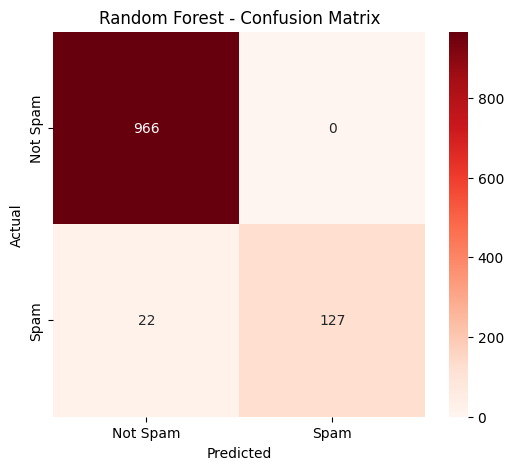

In [ ]:
# --- Random Forest ---
y_pred_rf = RF.predict(X_test_vec)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

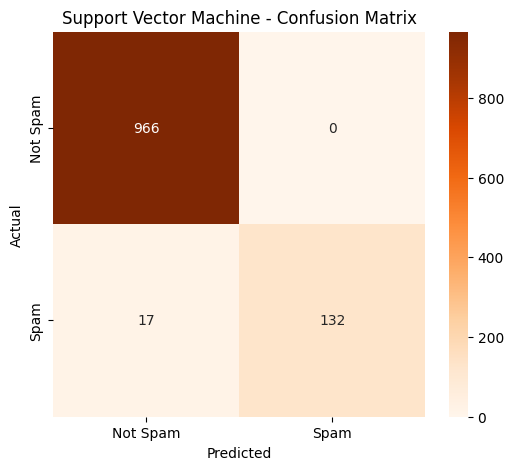

In [ ]:
# --- Support Vector Machine ---
y_pred_svc = svc.predict(X_test_vec)
cm_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Oranges', xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
plt.title("Support Vector Machine - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pickle

# Save Logistic Regression model
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(LR, file)
print("Logistic Regression model saved as 'logistic_regression_model.pkl'")

# Save Naïve Bayes model
with open('naive_bayes_model.pkl', 'wb') as file:
    pickle.dump(NB, file)
print("Naïve Bayes model saved as 'naive_bayes_model.pkl'")

# Save Decision Tree model
with open('decision_tree_model.pkl', 'wb') as file:
    pickle.dump(DT, file)
print("Decision Tree model saved as 'decision_tree_model.pkl'")

# Save Random Forest model
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(RF, file)
print("Random Forest model saved as 'random_forest_model.pkl'")

# Save Support Vector Machine model
with open('svc_model.pkl', 'wb') as file:
    pickle.dump(svc, file)
print("Support Vector Machine model saved as 'svc_model.pkl'")

Logistic Regression model saved as 'logistic_regression_model.pkl'
Naïve Bayes model saved as 'naive_bayes_model.pkl'
Decision Tree model saved as 'decision_tree_model.pkl'
Random Forest model saved as 'random_forest_model.pkl'
Support Vector Machine model saved as 'svc_model.pkl'
